# Data Project

In [5]:
# Importing necessary packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1.a

To examine the development of inequality in Denmark since 1987, we use statistics on the Gini coefficient and the total income share of the richest 10 percent. The data on the Gini coefficient and income is obtained from Statistics Denmark and used to illustrate the development of income inequality over time.

In [6]:
# Importing relevant data
from dstapi import DstApi

import Dataproject_1ab as dp

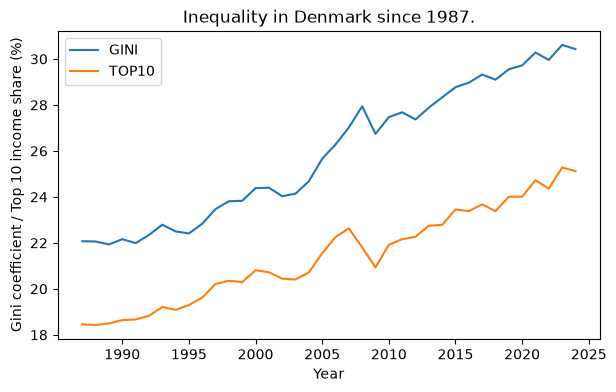

In [7]:
# Plotting figure 
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(dp.merged['TID'], dp.merged['GINI'], label='GINI')
ax.plot(dp.merged['TID'], dp.merged['TOP10'], label='TOP10')


ax.set_title('Inequality in Denmark since 1987.')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient / Top 10 income share (%)')
ax.legend();

In [8]:
# Calculation of correlation between GINI and TOP10

correlation = dp.merged['GINI'].corr(dp.merged['TOP10'])
print(f'Correlation between GINI and TOP10 is: {correlation:.6f}')

Correlation between GINI and TOP10 is: 0.981642


We find that inequality in Denmark has increased since 1987. The figure shows that both the Gini coefficient and the income share of the richest 10 percent have increased. The Gini coefficient has increased from around 22 to about 30, while the income share of the richest 10 percent has increased from about 18.5 percent to 24 percent. The two measures therefore show a similar development. This is also supported by the correlation of 0.98, which indicates a very strong positive relationship between the two measures.

## Question 1.b

Here we predict the inequality for the years 2030 and 2040, by creating both a linear and a quadratic trend to the Gini coefficient. 

First, we define t as the number of years since 1987 and y as the Gini coefficient. We then create a linear and a quadratic trend to describe how the Gini coefficient has developed over time. We use minimize to find the coefficients that make the predicted values as close as possible to the actual Gini values.

In [9]:
# Defining t (years) and y (Gini)

t = dp.merged['TID'] - 1987
y = dp.merged['GINI']

In [10]:
# Calculating linear 
def s_linear(beta):
    y_prediction = beta[0] + beta[1] * t
    sum = ((y - y_prediction) ** 2).sum()

    return sum

from scipy.optimize import minimize

result_linear = minimize(s_linear, [0, 0])

result_linear.x

array([21.04275355,  0.26354959])

In [11]:
# Calculating quadratic 
def s_quadratic(beta):
    y_prediction = beta[0] + beta[1]* t + beta[2] * t**2
    sum = ((y - y_prediction) ** 2).sum()

    return sum
    
from scipy.optimize import minimize
    
result_quadratic = minimize(s_quadratic, [0, 0, 0])
    
result_quadratic.x

array([2.13041867e+01, 2.19975902e-01, 1.17767450e-03])

In [12]:
# Calculating and comparing with np.polyfit for: 

# a) linear
print(np.polyfit(t, y, 1))

# b) quadratic
print(np.polyfit(t, y, 2))


[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


In [13]:
# Predicting the Gini coefficient in 2030 for:

t_2030 = 2030 - 1987

# a) linear

def s_linear_2030(beta):
    gini_linear_2030 =  beta[0] + beta[1] * t_2030

    return gini_linear_2030

print('Linear Gini in 2030 is:', s_linear_2030(result_linear.x))

# b) quadratic
def s_quadratic_2030(beta):
    gini_quadratic_2030 =  beta[0] + beta[1] * t_2030 + beta[2] * t_2030 **2

    return gini_quadratic_2030

print('Quadratic Gini in 2030 is:', s_quadratic_2030(result_quadratic.x))



Linear Gini in 2030 is: 32.37538611098807
Quadratic Gini in 2030 is: 32.94067063473604


In [14]:
# Predicting the Gini coefficient in 2040 for:

t_2040 = 2040 - 1987

# a) linear

def s_linear_2040(beta):
    gini_linear_2040 =  beta[0] + beta[1] * t_2040

    return gini_linear_2040

print('Linear Gini in 2040 is:', s_linear_2040(result_linear.x))

# b) quadratic
def s_quadratic_2040(beta):
    gini_quadratic_2040 =  beta[0] + beta[1] * t_2040 + beta[2] * t_2040 **2

    return gini_quadratic_2040

print('Quadratic Gini in 2040 is:', s_quadratic_2040(result_quadratic.x))


Linear Gini in 2040 is: 35.01088205439406
Quadratic Gini in 2040 is: 36.270997179924024


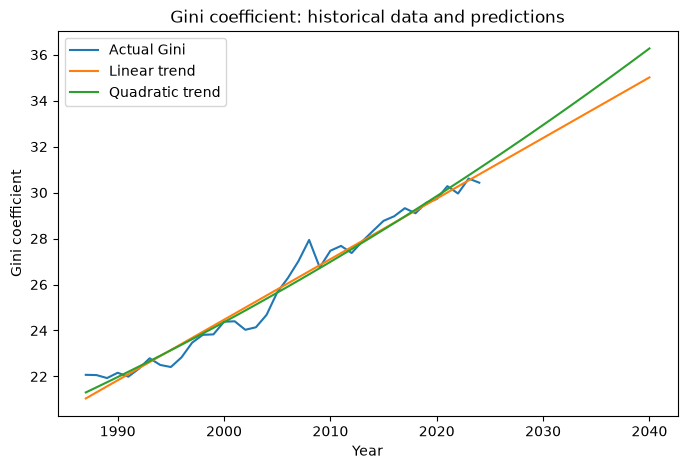

In [15]:
# Plotting the values 
years_plot = np.arange(1987, 2041)
t_plot = years_plot - 1987

beta_linear = result_linear.x
beta_quadratic = result_quadratic.x

gini_linear_plot = beta_linear[0] + beta_linear[1] * t_plot

gini_quadratic_plot = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

# Plotting the results in a figure 
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(dp.merged['TID'], dp.merged['GINI'], label='Actual Gini')
ax.plot(years_plot, gini_linear_plot, label='Linear trend')
ax.plot(years_plot, gini_quadratic_plot, label='Quadratic trend')

ax.set_title('Gini coefficient: historical data and predictions')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.legend()

The figure shows both the linear and quadratic predictions together with the actual Gini coefficient that we calculated in the previous question. The figure shows that both the linear and quadratic models follow a similar trend. The linear model is a straight line that assumes that Gini increases by the same amount every year. The quadratic model, however, allows the increase in Gini to vary over time. The predictions for 2030 and 2040 are slightly different. The linear model predicts a slightly smaller increase in Gini than the quadratic model.

Even though both models predict that Gini will continue to increase in the future, it is important to note that these models do not take economic or political events into account, which could influence the future development of the Gini coefficient. Therefore, these predictions should be taken with a grain of salt, since they predict developments far into the future.


##  Question 1.c

In [16]:
import Dataproject_1c as dp2

In [17]:
# Correlation between gini and Top10 incomers for municipalities
correlation_municipalities = dp2.merged_municipalities['GINI'].corr(
    dp2.merged_municipalities['TOP10']
)

print(f'Correlation between the munucipalities GINI and TOP10 is: {correlation_municipalities:.6f}')

Correlation between the munucipalities GINI and TOP10 is: 0.960545


In [18]:
# Convert GINI to numeric
dp2.gini_municipalities['GINI'] = pd.to_numeric(dp2.gini_municipalities['GINI'])

# Find the most recent year
recent_year = dp2.gini_municipalities['TID'].max()

# Keep observations from the most recent year
data_for_2024 = dp2.gini_municipalities[
    dp2.gini_municipalities['TID'] == recent_year
]

# Find the 10 municipalities with the highest Gini
most_unequal = data_for_2024.nlargest(10, 'GINI')

print('The top 10 most unequal municipalites are:')
display(most_unequal)

# Find the 10 municipalites with the lowest Gini
most_equal = data_for_2024.nsmallest(10, 'GINI')

print('')
print('The top 10 most equal municipalites are:')
display(most_equal)


The top 10 most unequal municipalites are:


,KOMMUNEDK,TID,GINI
3471,Gentofte,2024,49.04
3489,Rudersdal,2024,47.31
3529,Vejen,2024,46.32
3488,Hørsholm,2024,40.07
3478,Lyngby-Taarbæk,2024,39.28
3467,Frederiksberg,2024,36.54
3466,Copenhagen,2024,34.97
3547,Aarhus,2024,33.43
3485,Fredensborg,2024,32.76
3486,Helsingør,2024,30.55



The top 10 most equal municipalites are:


,KOMMUNEDK,TID,GINI
3514,Faaborg-Midtfyn,2024,23.77
3490,Egedal,2024,23.85
3511,Bornholm,2024,24.03
3500,Faxe,2024,24.09
3494,Halsnæs,2024,24.41
3541,Favrskov,2024,24.41
3513,Assens,2024,24.46
3550,Hedensted,2024,24.58
3475,Albertslund,2024,24.66
3542,Odder,2024,24.70


The least equal:


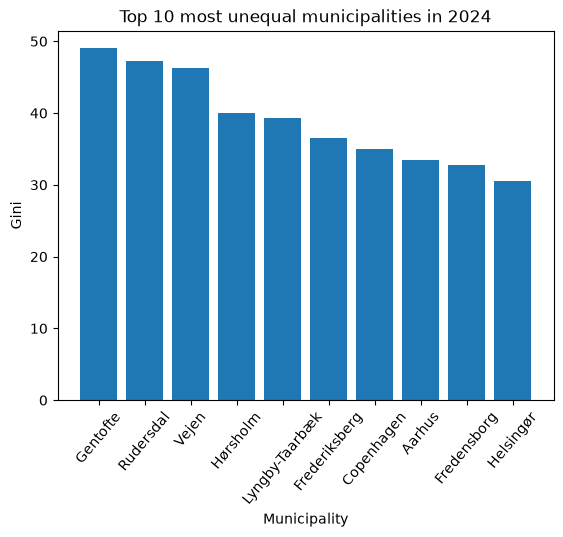


The most equal:


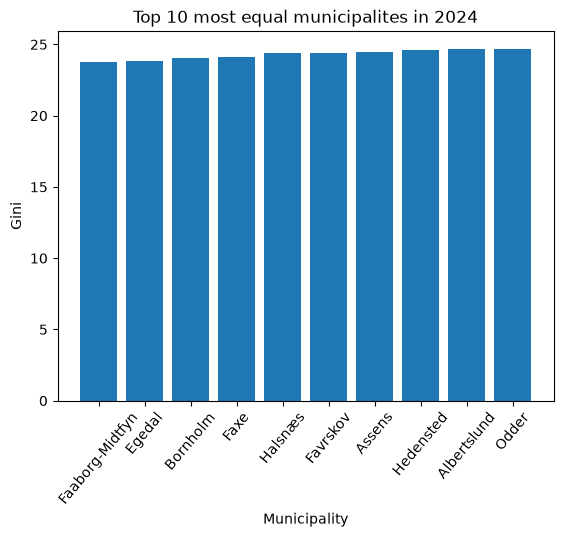

In [19]:
# Plotting the data into figures:

# a) for the 10 most unequal
plt.bar(most_unequal['KOMMUNEDK'], most_unequal['GINI'])

plt.xlabel('Municipality')
plt.ylabel('Gini')
plt.title('Top 10 most unequal municipalities in 2024')

plt.xticks(rotation = 50)

print('The least equal:')
plt.show()

# b) for the 10 most equal
plt.bar(most_equal['KOMMUNEDK'], most_equal['GINI'])

plt.xlabel('Municipality')
plt.ylabel('Gini')
plt.title('Top 10 most equal municipalites in 2024')

plt.xticks(rotation = 50)

print('')
print('The most equal:')
plt.show()

The two figures show the 10 most and the 10 least unequal municipalities in the most recent year, 2024. Gentofte has the highest Gini coefficient at almost 50, followed by Rudersdal and Vejen, which both have a Gini coefficient of around 47–48. The municipalities with the lowest Gini coefficients are much closer to each other, with values around 24–25.

The most noteworthy observation from the figures is that there is a larger difference between the municipalities at the top of the ranking than between those at the bottom. This indicates that there is greater variation in income inequality among the most unequal municipalities, while the least unequal municipalities have relatively similar levels of inequality.

In [20]:
first_year = dp2.gini_municipalities['TID'].min()
latest_year = dp2.gini_municipalities['TID'].max()

print(first_year, latest_year) 

1987 2024


In [21]:
# Find the first and the most recent year in the data
first_year = dp2.gini_municipalities['TID'].min()
latest_year = dp2.gini_municipalities['TID'].max()

# Select Gini data from the first year
gini_first = dp2.gini_municipalities[
    dp2.gini_municipalities['TID'] == first_year
]

# Select Gini data from the most recent year
gini_latest = dp2.gini_municipalities[
    dp2.gini_municipalities['TID'] == latest_year
]

# Merge the first and latest year by municipality
gini_change = pd.merge(
    gini_first,
    gini_latest,
    on='KOMMUNEDK',
    how='inner',
    suffixes=('_first', '_latest')
)

# Calculate the change in Gini between the first and latest year
gini_change['CHANGE'] = (
    gini_change['GINI_latest'] - gini_change['GINI_first']
)

# Find the municipalities with the largest and smallest change in Gini
largest_change = gini_change.nlargest(1, 'CHANGE')
smallest_change = gini_change.nsmallest(1, 'CHANGE')

display(largest_change)
display(smallest_change)

,KOMMUNEDK,TID_first,GINI_first,TID_latest,GINI_latest,CHANGE
64,Vejen,1987,21.2,2024,46.32,25.12


,KOMMUNEDK,TID_first,GINI_first,TID_latest,GINI_latest,CHANGE
62,Fanø,1987,25.67,2024,26.34,0.67


Vejen shows the largest increase in the Gini coefficient, rising from 21.20 in 1987 to 46.32 in 2024. Fanø shows the smallest change, increasing only from 25.67 to 26.34. This suggests that income inequality has increased much more strongly in Vejen than in Fanø over the period.

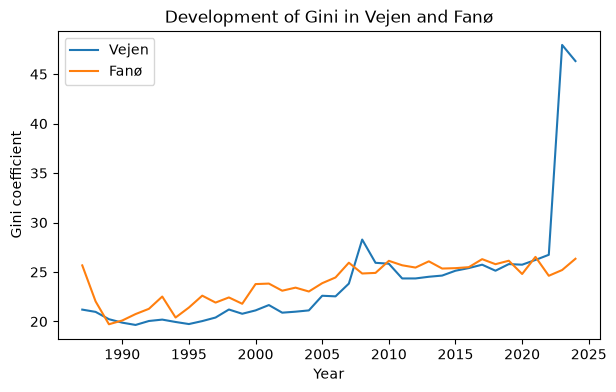

In [22]:
# Select data for Vejen and Fanø
vejen = dp2.gini_municipalities[
    dp2.gini_municipalities['KOMMUNEDK'] == 'Vejen'
]

fano = dp2.gini_municipalities[
    dp2.gini_municipalities['KOMMUNEDK'] == 'Fanø'
]

# Plot the development of Gini over time
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)

# Sorting after the years 
vejen = vejen.sort_values('TID')
fano = fano.sort_values('TID')

ax.plot(vejen['TID'], vejen['GINI'], label='Vejen')
ax.plot(fano['TID'], fano['GINI'], label='Fanø')

ax.set_title('Development of Gini in Vejen and Fanø')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.legend()
plt.show()

The figure shows the development of the Gini coefficient in Vejen and Fanø from 1987 to 2024. Fanø has a relatively stable development, with only a small increase in the Gini coefficient over time. Vejen follows a similar pattern for most of the period, but shows a very large increase in the final years. This explains why Vejen has the largest change in the Gini coefficient, while Fanø has the smallest change.

## Question 1.d

In [23]:
import Dataproject_1d as dp3

display(dp3.merged_municipalities_part2.head())

,KOMMUNEDK,TID,GINI,AVERAGE_DISPOSABLE_INCOME
0,All Denmark,2016,28.97,358674
1,Copenhagen,2016,33.24,300124
2,Frederiksberg,2016,34.85,368526
3,Ballerup,2016,25.77,369497
4,Brøndby,2016,25.71,322962


In [24]:
# Correlation between Gini and average disposable incomes for municipalities
correlation_municipalities_part2 = dp3.merged_municipalities_part2['GINI'].corr(
    dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME']
)

print(f'The correlation between the munucipalities gini and  average disposable incomes is: {correlation_municipalities_part2:.6f}')

The correlation between the munucipalities gini and  average disposable incomes is: 0.661542


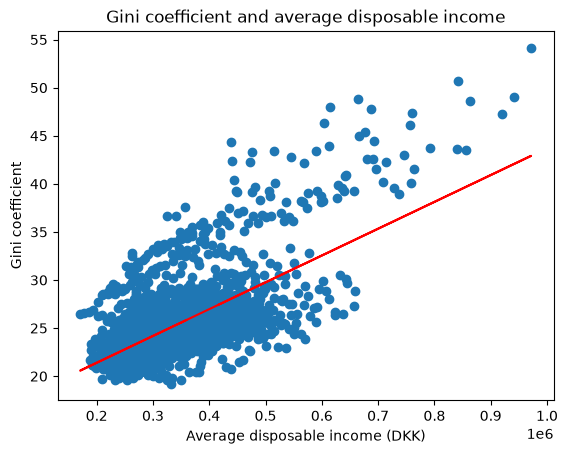

In [25]:
# Creating a scatterplot 

import matplotlib.pyplot as plt
import numpy as np

    #Convert Gini and average disposable income to numeric values
dp3.merged_municipalities_part2['GINI'] = pd.to_numeric(
    dp3.merged_municipalities_part2['GINI']
)

dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME'] = pd.to_numeric(
    dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME']
)

x = dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME'].to_numpy()
y = dp3.merged_municipalities_part2['GINI'].to_numpy()


plt.scatter(x, y)

# Add a linear trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

plt.xlabel('Average disposable income (DKK)')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient and average disposable income')


plt.show()

The figure shows a positive relationship between average disposable income and the Gini coefficient. Municipalities with higher average disposable income generally tend to have a higher Gini coefficient. This suggests that municipalities with higher average incomes also tend to have greater income inequality. However, the observations are quite spread out, so the relationship is not perfect. The figure shows a correlation, but this does not necessarily mean that higher income causes higher inequality.